## Model Terminology

| Short Name        | Class Name                | Description                 |
|-------------------|--------------------------|-----------------------------| 
| `dense`           | DenseTransformer         | Standard term               |
| `iter`            | IterativeTransformer     | "Iterates" same block       |
| `iter_step`       | IterativeStepTransformer | + step awareness            |
| `adaptive`        | AdaptiveTransformer      | "Adaptive" is from ACT      |
| `adaptive_dual`   | AdaptiveDual             | + dual stream               |
| `adaptive_nested` | AdaptiveNested           | + nested hierarchy          |
| `terminal_nested` | Autoregressive TRM       | Final/terminal iterate      |

*Single stream* models are above the dividing line, *dual stream* below.

In [30]:
# Mapping from model names in CSV files to Transformer class names
model_to_class = {
    'gpt': 'DenseTransformer',
    'gpt_level1': 'Iterative Transformer',
    'gpt_level2': 'Iterative StepTransformer',
    'ut': 'Universal Transformer (UT)',
    'ut_level1': 'Dual UT',
    'ut_level2': 'Dual Nested UT',
    'trm': 'Autoregressive TRM'
}

In [5]:
import pandas as pd

# Set data directory path
data_dir = './data/'

# Read all CSV files with abbreviated names
# co = compute_optimal, hl = hl_structure, lg = lengthgen_train
# pi = paraminf_scaling, tl = trainlen_scaling
# h = history, s = summary

co_h = pd.read_csv(f"{data_dir}compute_optimal_history.csv")
co_s = pd.read_csv(f"{data_dir}compute_optimal_summary.csv")

hl_h = pd.read_csv(f"{data_dir}hl_structure_history.csv")
hl_s = pd.read_csv(f"{data_dir}hl_structure_summary.csv")

lg_h = pd.read_csv(f"{data_dir}lengthgen_train_history.csv")
lg_s = pd.read_csv(f"{data_dir}lengthgen_train_summary.csv")

pi_h = pd.read_csv(f"{data_dir}paraminf_scaling_history.csv")
pi_s = pd.read_csv(f"{data_dir}paraminf_scaling_summary.csv")

tl_h = pd.read_csv(f"{data_dir}trainlen_scaling_history.csv")
tl_s = pd.read_csv(f"{data_dir}trainlen_scaling_summary.csv")

In [31]:
# =============================================================================
# THE ECONOMIST STYLE COLOR PALETTE
# =============================================================================
# Grouped by model family with varying saturation/lightness for levels

ECONOMIST_COLORS = {
    # --- Dense Transformer Family (Navy/Blue) ---
    'gpt': '#0D5288',           # Economist Navy (base)
    'gpt_level1': '#3A7CA5',    # Medium blue
    'gpt_level2': '#6BA3C9',    # Light blue
    
    # --- Universal Transformer Family (Teal/Green) ---
    'ut': '#00837B',            # Economist Teal (base)
    'ut_level1': '#2FA89E',     # Medium teal
    'ut_level2': '#5FCEC3',     # Light teal
    
    # --- Terminal Nested (Economist Red) ---
    'trm': '#E3120B',           # Economist Signature Red
}

# With readable display names
MODEL_STYLES = {
    'gpt':       {'color': '#0D5288', 'name': 'Dense Transformer'},
    'gpt_level1': {'color': '#3A7CA5', 'name': 'Dense Transformer (L1)'},
    'gpt_level2': {'color': '#6BA3C9', 'name': 'Dense Transformer (L2)'},
    'ut':        {'color': '#00837B', 'name': 'Universal Transformer'},
    'ut_level1': {'color': '#2FA89E', 'name': 'Universal Transformer (L1)'},
    'ut_level2': {'color': '#5FCEC3', 'name': 'Universal Transformer (L2)'},
    'trm':       {'color': '#E3120B', 'name': 'Autoregressive TRM'},
}

# Extract just colors and names for convenience
COLORS = {k: v['color'] for k, v in MODEL_STYLES.items()}
NAMES = {k: v['name'] for k, v in MODEL_STYLES.items()}

# =============================================================================
# ECONOMIST PLOT STYLING
# =============================================================================
import matplotlib.pyplot as plt

def set_economist_style():
    """Apply Economist-inspired matplotlib styling"""
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
        'font.size': 11,
        'axes.titlesize': 14,
        'axes.titleweight': 'bold',
        'axes.labelsize': 11,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.edgecolor': '#333333',
        'axes.linewidth': 1.0,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        'legend.fontsize': 10,
        'legend.frameon': False,
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'axes.grid': True,
        'grid.alpha': 0.3,
        'grid.linewidth': 0.5,
        'grid.color': '#cccccc',
    })

# Call this at the start of your notebook
set_economist_style()

# 1. Model performance across tasks

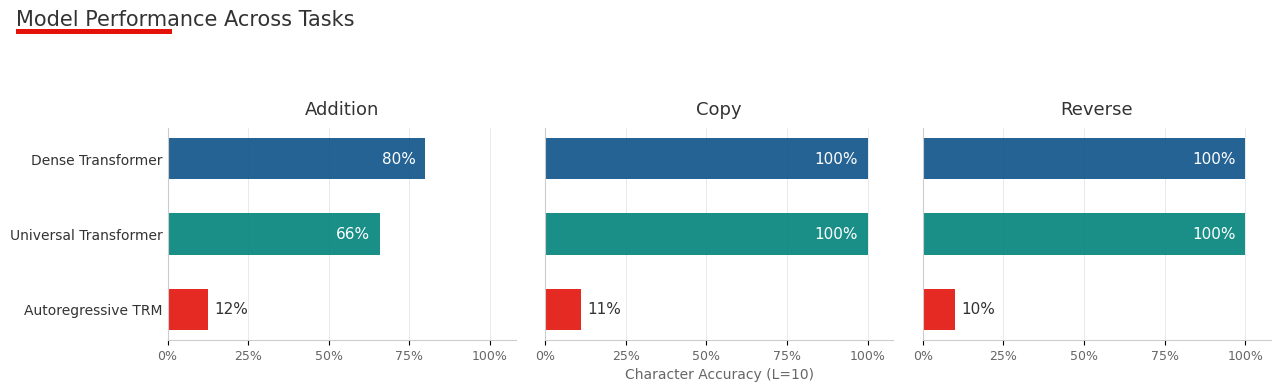


──────────────────────────────────────────────────────────────
  MODEL PERFORMANCE SUMMARY (L10 Character Accuracy, Compute=24)
──────────────────────────────────────────────────────────────
  Model                        Addition       Copy    Reverse
──────────────────────────────────────────────────────────────
  Dense Transformer               79.9%     100.0%     100.0%
  Universal Transformer           65.8%     100.0%     100.0%
  Autoregressive TRM              12.5%      11.0%      10.0%
──────────────────────────────────────────────────────────────


In [35]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =============================================================================
# ECONOMIST STYLE SETUP
# =============================================================================
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica Neue', 'Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 13,
    'axes.titlesize': 13,
    'axes.titleweight': 'normal',  # remove bold
    'axes.labelsize': 13,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.8,
    'xtick.labelsize': 9,
    'ytick.labelsize': 10,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

# Model mapping
model_names = {
    'gpt': 'Dense Transformer',
    'ut': 'Universal Transformer', 
    'trm': 'Autoregressive TRM'
}

# Economist color palette
COLORS = {
    'gpt': '#0D5288',   # Economist Navy
    'ut': '#00837B',    # Economist Teal
    'trm': '#E3120B',   # Economist Red
}

# Filter to base models
base_models = ['gpt', 'ut', 'trm']

# --- Filter lg_s by compute budget 24 and base models ---
lg_s_filtered = lg_s[(lg_s['model'].isin(base_models)) & (lg_s['compute_budget'] == 24)].copy()

# Get results for each task (directly filtered, not "best")
best_addition = lg_s_filtered[lg_s_filtered['task'] == 'addition']
best_copy = lg_s_filtered[lg_s_filtered['task'] == 'copy']
best_reverse = lg_s_filtered[lg_s_filtered['task'] == 'reverse']

# Prepare data
tasks = ['Addition', 'Copy', 'Reverse']
task_data = [best_addition, best_copy, best_reverse]
model_order = ['gpt', 'ut', 'trm']

# =============================================================================
# CREATE FIGURE
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
fig.patch.set_facecolor('white')

for ax, task_name, df in zip(axes, tasks, task_data):
    y_positions = []
    accuracies = []
    bar_colors = []
    labels = []
    
    for i, model in enumerate(model_order):
        row = df[df['model'] == model]
        if len(row) > 0:
            acc = row['L10_char_acc'].values[0]
            y_positions.append(i)
            accuracies.append(acc)
            bar_colors.append(COLORS[model])
            labels.append(model_names[model])
    
    # Horizontal bars
    bars = ax.barh(y_positions, accuracies, color=bar_colors, 
                   edgecolor='none', height=0.55, alpha=0.9)
    
    # Add accuracy labels
    for bar, acc in zip(bars, accuracies):
        width = bar.get_width()
        # Position text inside bar if >50%, outside if smaller
        if acc > 0.5:
            ax.text(width - 0.03, bar.get_y() + bar.get_height()/2, 
                    f'{acc:.0%}', va='center', ha='right', 
                    fontsize=11, fontweight='normal', color='white')
        else:
            ax.text(width + 0.02, bar.get_y() + bar.get_height()/2, 
                    f'{acc:.0%}', va='center', ha='left', 
                    fontsize=11, fontweight='normal', color='#333333')
    
    ax.set_yticks(y_positions)
    ax.set_yticklabels(labels, fontsize=10, color='#333333')
    ax.set_xlim(0, 1.08)
    ax.set_title(task_name, fontsize=13, fontweight='normal', color='#333333', pad=10)
    
    # Subtle gridlines
    ax.xaxis.grid(True, linestyle='-', alpha=0.2, color='#666666')
    ax.yaxis.grid(False)
    ax.set_axisbelow(True)
    
    # Clean up spines
    ax.spines['left'].set_color('#cccccc')
    ax.spines['bottom'].set_color('#cccccc')
    
    # X-axis formatting
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_xticklabels(['0%', '25%', '50%', '75%', '100%'], color='#666666')
    
    # Remove y-axis ticks (keep labels)
    ax.tick_params(axis='y', length=0)

# Only show x-label on middle subplot
axes[1].set_xlabel('Character Accuracy (L=10)', fontsize=10, color='#666666')

# Invert y-axis so Dense is at top
for ax in axes:
    ax.invert_yaxis()

# Title with Economist-style red accent line
fig.suptitle('Model Performance Across Tasks', fontsize=15, fontweight='normal', 
             color='#333333', x=0.02, ha='left', y=0.98)

# Add red accent line under title (Economist signature)
fig.patches.append(plt.Rectangle((0.02, 0.92), 0.12, 0.012, 
                                   transform=fig.transFigure, 
                                   facecolor='#E3120B', edgecolor='none'))

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig('model_performance_summary.pdf')
plt.show()

# =============================================================================
# SUMMARY TABLE
# =============================================================================
print("\n" + "─"*62)
print("  MODEL PERFORMANCE SUMMARY (L10 Character Accuracy, Compute=24)")
print("─"*62)
print(f"  {'Model':<26} {'Addition':>10} {'Copy':>10} {'Reverse':>10}")
print("─"*62)
for model in model_order:
    name = model_names[model]
    add_acc = best_addition[best_addition['model'] == model]['L10_char_acc'].values[0]
    copy_acc = best_copy[best_copy['model'] == model]['L10_char_acc'].values[0]
    rev_acc = best_reverse[best_reverse['model'] == model]['L10_char_acc'].values[0]
    print(f"  {name:<26} {add_acc:>10.1%} {copy_acc:>10.1%} {rev_acc:>10.1%}")
print("─"*62)

# 2. Performance by model stream

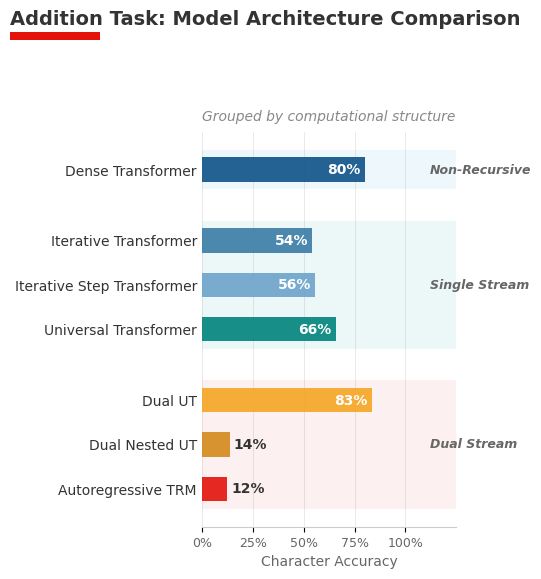

In [37]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =============================================================================
# ECONOMIST STYLE SETUP
# =============================================================================
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica Neue', 'Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.8,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

# =============================================================================
# MODEL CONFIGURATION
# =============================================================================
MODEL_CONFIG = {
    # Non-Recursive (Feedforward)
    'gpt':       {'name': 'Dense Transformer',           'category': 'Non-Recursive', 'color': '#0D5288'},
    
    # Single Stream (Recursive)
    'gpt_level1': {'name': 'Iterative Transformer',      'category': 'Single Stream', 'color': '#3A7CA5'},
    'gpt_level2': {'name': 'Iterative Step Transformer', 'category': 'Single Stream', 'color': '#6BA3C9'},
    'ut':         {'name': 'Universal Transformer',      'category': 'Single Stream', 'color': '#00837B'},
    
    # Dual Stream (Recursive)
    'ut_level1': {'name': 'Dual UT',                     'category': 'Dual Stream', 'color': '#F5A623'},
    'ut_level2': {'name': 'Dual Nested UT',              'category': 'Dual Stream', 'color': '#D4891C'},
    'trm':       {'name': 'Autoregressive TRM', 'category': 'Dual Stream', 'color': '#E3120B'},
}

# Category colors for backgrounds
CATEGORY_COLORS = {
    'Non-Recursive': '#E8F4FC',  # Light blue
    'Single Stream': '#E5F5F4',  # Light teal
    'Dual Stream':   '#FDEAEA',  # Light red
}

# Order: grouped by category
model_order = ['gpt', 'gpt_level1', 'gpt_level2', 'ut', 'ut_level1', 'ut_level2', 'trm']

# =============================================================================
# GET DATA (Addition task only)
# =============================================================================
addition_data = lg_s[lg_s['model'].isin(model_order)].copy()
addition_data = addition_data[addition_data['task'] == 'addition'].copy()
addition_data = addition_data[addition_data['compute_budget'] == 24].copy()
best_results = addition_data.loc[addition_data.groupby('model')['L10_char_acc'].idxmax()]

# =============================================================================
# CREATE FIGURE
# =============================================================================
fig, ax = plt.subplots(figsize=(6, 6))
fig.patch.set_facecolor('white')

# Calculate positions with gaps between categories
positions = []
current_pos = 0
category_spans = {}
prev_category = None

for model in model_order:
    category = MODEL_CONFIG[model]['category']
    
    if prev_category and category != prev_category:
        current_pos += 0.6
    
    if category not in category_spans:
        category_spans[category] = {'start': current_pos, 'end': current_pos}
    else:
        category_spans[category]['end'] = current_pos
    
    positions.append(current_pos)
    prev_category = category
    current_pos += 1

# Draw category background shading
for category, span in category_spans.items():
    ax.axhspan(span['start'] - 0.45, span['end'] + 0.45, 
               facecolor=CATEGORY_COLORS[category], edgecolor='none', alpha=0.7, zorder=0)
    mid_y = (span['start'] + span['end']) / 2
    ax.text(1.12, mid_y, category, va='center', ha='left', fontsize=9, 
            fontweight='bold', color='#666666', style='italic')

# Draw bars
for pos, model in zip(positions, model_order):
    row = best_results[best_results['model'] == model]
    if len(row) > 0:
        acc = row['L10_char_acc'].values[0]
        config = MODEL_CONFIG[model]
        
        bar = ax.barh(pos, acc, color=config['color'], height=0.55, 
                      edgecolor='none', alpha=0.9, zorder=2)
        
        if acc > 0.5:
            ax.text(acc - 0.02, pos, f'{acc:.0%}', va='center', ha='right',
                    fontsize=10, fontweight='bold', color='white', zorder=3)
        else:
            ax.text(acc + 0.02, pos, f'{acc:.0%}', va='center', ha='left',
                    fontsize=10, fontweight='bold', color='#333333', zorder=3)

# Y-axis labels
ax.set_yticks(positions)
ax.set_yticklabels([MODEL_CONFIG[m]['name'] for m in model_order], fontsize=10, color='#333333')

# X-axis formatting
ax.set_xlim(0, 1.25)
ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_xticklabels(['0%', '25%', '50%', '75%', '100%'], color='#666666')
ax.set_xlabel('Character Accuracy', fontsize=10, color='#666666')

# Grid
ax.xaxis.grid(True, linestyle='-', alpha=0.3, color='#999999', zorder=1)
ax.yaxis.grid(False)
ax.set_axisbelow(True)

# Spines
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#cccccc')
ax.tick_params(axis='y', length=0)

# Invert y-axis
ax.invert_yaxis()

# Title with red accent
fig.suptitle('Addition Task: Model Architecture Comparison', 
             fontsize=14, fontweight='bold', color='#333333', x=0.02, ha='left', y=0.96)
ax.set_title('Grouped by computational structure', fontsize=10, color='#888888', 
             loc='left', pad=8, style='italic')

# Red accent line
fig.patches.append(plt.Rectangle((0.02, 0.91), 0.15, 0.012, 
                                   transform=fig.transFigure, 
                                   facecolor='#E3120B', edgecolor='none'))

plt.tight_layout(rect=[0, 0, 0.88, 0.88])
plt.show()

# 3. Accuracy by output position

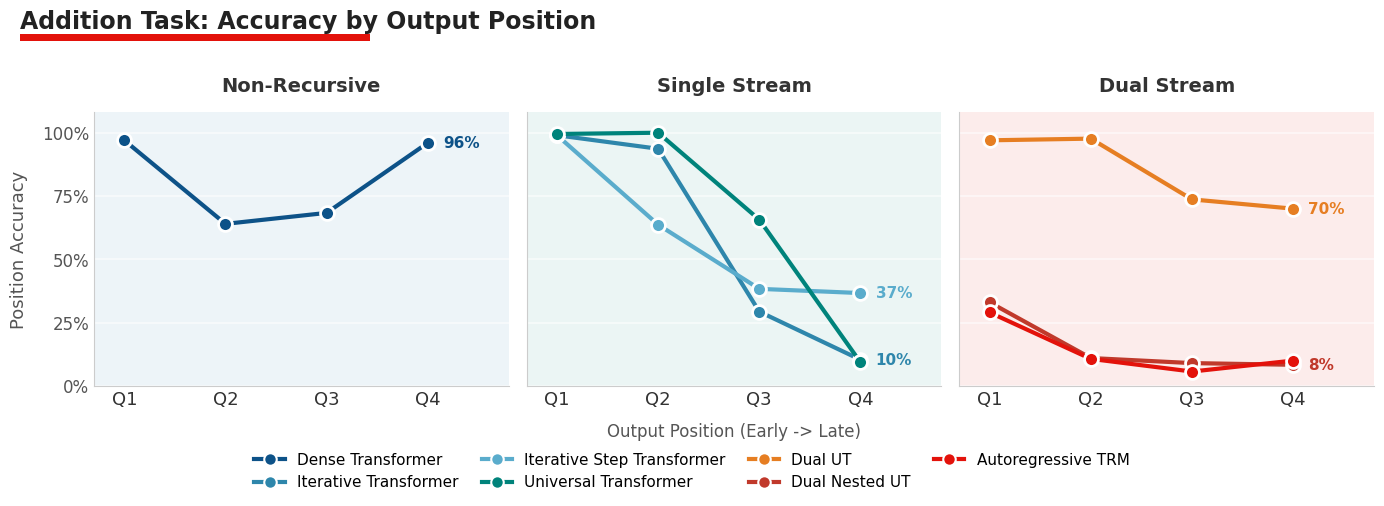

In [39]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =============================================================================
# STYLE SETUP
# =============================================================================
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica Neue', 'Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.8,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

# =============================================================================
# MODEL CONFIGURATION - CONSISTENT COLORS
# =============================================================================
MODEL_CONFIG = {
    'gpt':        {'name': 'Dense Transformer',           'category': 'Non-Recursive', 'color': '#0D5288'},
    'gpt_level1': {'name': 'Iterative Transformer',       'category': 'Single Stream', 'color': '#2E86AB'},
    'gpt_level2': {'name': 'Iterative Step Transformer',  'category': 'Single Stream', 'color': '#5AACCC'},
    'ut':         {'name': 'Universal Transformer',       'category': 'Single Stream', 'color': '#00837B'},
    'ut_level1':  {'name': 'Dual UT',                     'category': 'Dual Stream',   'color': '#E67E22'},
    'ut_level2':  {'name': 'Dual Nested UT',              'category': 'Dual Stream',   'color': '#C0392B'},
    'trm':        {'name': 'Autoregressive TRM', 'category': 'Dual Stream',   'color': '#E3120B'},
}

CATEGORY_BG = {
    'Non-Recursive': '#EDF4F8',
    'Single Stream': '#EBF5F4',
    'Dual Stream':   '#FCECEB',
}

model_order = ['gpt', 'gpt_level1', 'gpt_level2', 'ut', 'ut_level1', 'ut_level2', 'trm']
positions = ['Q1', 'Q2', 'Q3', 'Q4']
pos_cols = ['L10_pos_q1_acc', 'L10_pos_q2_acc', 'L10_pos_q3_acc', 'L10_pos_q4_acc']

# =============================================================================
# GET DATA
# =============================================================================
#addition_data = co_s[co_s['model'].isin(model_order)].copy()
addition_data = lg_s[lg_s['model'].isin(model_order)].copy()
addition_data = addition_data[addition_data['task'] == 'addition'].copy()
addition_data = addition_data[addition_data['compute_budget'] == 24].copy()
best_results = addition_data.loc[addition_data.groupby('model')['L10_char_acc'].idxmax()]
#best_results = addition_data.groupby('model')[pos_cols].mean().reset_index()

# =============================================================================
# CREATE FIGURE
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
fig.patch.set_facecolor('white')

categories = ['Non-Recursive', 'Single Stream', 'Dual Stream']
x = np.arange(len(positions))

for ax, category in zip(axes, categories):
    ax.set_facecolor(CATEGORY_BG[category])
    
    cat_models = [m for m in model_order if MODEL_CONFIG[m]['category'] == category]
    
    # Store endpoint values for smart labeling
    endpoints = []
    
    for model in cat_models:
        row = best_results[best_results['model'] == model]
        if len(row) > 0:
            config = MODEL_CONFIG[model]
            q_values = [row[col].values[0] for col in pos_cols]
            
            ax.plot(x, q_values, 
                    color=config['color'], 
                    linewidth=3, 
                    marker='o', 
                    markersize=10,
                    markerfacecolor=config['color'],
                    markeredgecolor='white',
                    markeredgewidth=2,
                    label=config['name'],
                    zorder=3)
            #print(model)
            if model != 'ut' and model != 'trm':  # Skip label for Iterative Step Transformer
                endpoints.append({'model': model, 'q4': q_values[3], 'color': config['color']})
    
    # Smart label placement at Q4 only - stagger if overlapping
    endpoints_sorted = sorted(endpoints, key=lambda e: e['q4'], reverse=True)
    prev_y = None
    
    for i, ep in enumerate(endpoints_sorted):
        y = ep['q4']
        # Stagger labels if too close
        if prev_y is not None and abs(y - prev_y) < 0.07:
            x_offset = 0.35
        else:
            x_offset = 0.15
        
        ax.text(3 + x_offset, y, f"{y:.0%}", 
                va='center', ha='left', fontsize=11, 
                color=ep['color'], fontweight='bold')
        prev_y = y
    
    # Axis formatting
    ax.set_xticks(x)
    ax.set_xticklabels(positions, fontsize=13, color='#333333')
    ax.set_xlim(-0.3, 3.8)
    ax.set_ylim(0, 1.08)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0%', '25%', '50%', '75%', '100%'], fontsize=12, color='#555555')
    
    # Grid
    ax.yaxis.grid(True, linestyle='-', alpha=0.5, color='white', linewidth=1.5, zorder=1)
    ax.xaxis.grid(False)
    
    # Category title
    ax.set_title(category, fontsize=14, fontweight='bold', color='#333333', pad=15)
    
    # Clean spines
    ax.spines['left'].set_color('#cccccc')
    ax.spines['bottom'].set_color('#cccccc')
    ax.tick_params(axis='both', length=0)

# Y-axis label
axes[0].set_ylabel('Position Accuracy', fontsize=13, color='#555555', labelpad=10)

# X-axis label (center plot only)
axes[1].set_xlabel('Output Position (Early -> Late)', fontsize=12, color='#555555', labelpad=10)

# Collect legend handles
handles, labels = [], []
for model in model_order:
    config = MODEL_CONFIG[model]
    line = plt.Line2D([0], [0], color=config['color'], linewidth=3, 
                       marker='o', markersize=9, markerfacecolor=config['color'],
                       markeredgecolor='white', markeredgewidth=1.5)
    handles.append(line)
    labels.append(config['name'])

# Legend below
fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=11, 
           frameon=False, bbox_to_anchor=(0.5, -0.01), columnspacing=1.5)

# Title with red accent
fig.text(0.02, 0.94, 'Addition Task: Accuracy by Output Position', 
         fontsize=17, fontweight='bold', color='#222222')
fig.patches.append(plt.Rectangle((0.02, 0.915), 0.25, 0.015, 
                                   transform=fig.transFigure, 
                                   facecolor='#E3120B', edgecolor='none'))

plt.tight_layout(rect=[0, 0.08, 1, 0.88])
plt.show()
fig.savefig('addition_task_position_accuracy.pdf')

# 4. Learning Dynamics

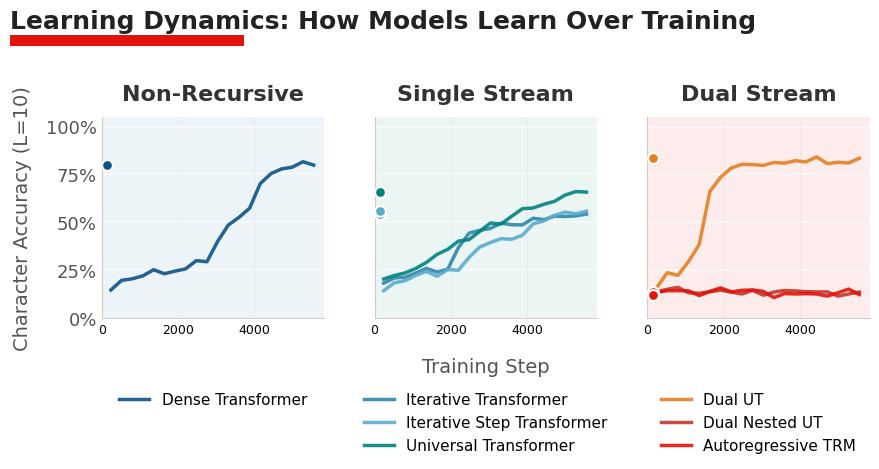

In [41]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =============================================================================
# STYLE SETUP
# =============================================================================
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica Neue', 'Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 14,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.8,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

# =============================================================================
# MODEL CONFIGURATION
# =============================================================================
MODEL_CONFIG = {
    'gpt':        {'name': 'Dense Transformer',           'category': 'Non-Recursive', 'color': '#0D5288'},
    'gpt_level1': {'name': 'Iterative Transformer',       'category': 'Single Stream', 'color': '#2E86AB'},
    'gpt_level2': {'name': 'Iterative Step Transformer',  'category': 'Single Stream', 'color': '#5AACCC'},
    'ut':         {'name': 'Universal Transformer',       'category': 'Single Stream', 'color': '#00837B'},
    'ut_level1':  {'name': 'Dual UT',                     'category': 'Dual Stream',   'color': '#E67E22'},
    'ut_level2':  {'name': 'Dual Nested UT',              'category': 'Dual Stream',   'color': '#C0392B'},
    'trm':        {'name': 'Autoregressive TRM', 'category': 'Dual Stream',   'color': '#E3120B'},
}

CATEGORY_BG = {
    'Non-Recursive': '#EDF4F8',
    'Single Stream': '#EBF5F4',
    'Dual Stream':   '#FCECEB',
}

model_order = ['gpt', 'gpt_level1', 'gpt_level2', 'ut', 'ut_level1', 'ut_level2', 'trm']

# =============================================================================
# PREPARE DATA
# =============================================================================
# Filter to our models
addition_data = lg_h[lg_h['model'].isin(model_order)].copy()
addition_data = addition_data[addition_data['task'] == 'addition'].copy()
addition_data = addition_data[addition_data['compute_budget'] == 24].copy()
history_data = addition_data.copy()

# Get the best run per model (highest final L10_char_acc)
# First find final step per run
final_steps = history_data.groupby('run_id')['step'].max().reset_index()
final_steps.columns = ['run_id', 'final_step']

# Merge to get final accuracy
history_with_final = history_data.merge(final_steps, on='run_id')
final_accs = history_with_final[history_with_final['step'] == history_with_final['final_step']]
best_runs = final_accs.loc[final_accs.groupby('model')['L10_char_acc'].idxmax(), 'run_id'].values

# Filter history to best runs only
best_history = history_data[history_data['run_id'].isin(best_runs)]

# =============================================================================
# CREATE FIGURE
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(9, 7), sharey=True)
fig.patch.set_facecolor('white')

categories = ['Non-Recursive', 'Single Stream', 'Dual Stream']

for ax, category in zip(axes, categories):
    ax.set_facecolor(CATEGORY_BG[category])
    
    cat_models = [m for m in model_order if MODEL_CONFIG[m]['category'] == category]
    
    for model in cat_models:
        config = MODEL_CONFIG[model]
        model_data = best_history[best_history['model'] == model].sort_values('step')
        
        if len(model_data) > 0:
            ax.plot(model_data['step']*40, model_data['L10_char_acc'],
                    color=config['color'],
                    linewidth=2.5,
                    label=config['name'],
                    alpha=0.9,
                    zorder=3)
            
            # Mark final point
            final_row = model_data.iloc[-1]
            ax.scatter(final_row['step'], final_row['L10_char_acc'],
                      color=config['color'], s=60, zorder=4,
                      edgecolor='white', linewidth=1.5)
    
    # Formatting
    ax.set_xlim(0, None)
    ax.set_ylim(0, 1.05)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0%', '25%', '50%', '75%', '100%'], fontsize=13, color='#555555')
    
    # Grid
    ax.yaxis.grid(True, linestyle='-', alpha=0.5, color='white', linewidth=1.5, zorder=1)
    ax.xaxis.grid(True, linestyle='-', alpha=0.3, color='#cccccc', linewidth=0.5, zorder=1)
    
    # Title
    ax.set_title(category, fontsize=16, fontweight='bold', color='#333333', pad=12)
    
    # Spines
    ax.spines['left'].set_color('#cccccc')
    ax.spines['bottom'].set_color('#cccccc')
    ax.tick_params(axis='both', length=0)
    
    # Legend BELOW each subplot
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), 
              fontsize=11, frameon=False, ncol=1)

# Axis labels
axes[0].set_ylabel('Character Accuracy (L=10)', fontsize=14, color='#555555', labelpad=10)
axes[1].set_xlabel('Training Step', fontsize=14, color='#555555', labelpad=15)

# Title
fig.text(0.02, 0.97, 'Learning Dynamics: How Models Learn Over Training', 
         fontsize=18, fontweight='bold', color='#222222')
fig.patches.append(plt.Rectangle((0.02, 0.945), 0.26, 0.015, 
                                   transform=fig.transFigure, 
                                   facecolor='#E3120B', edgecolor='none'))
plt.tight_layout(rect=[0, 0.18, 1, 0.92])
plt.savefig('learning_dynamics.pdf')
plt.show()


# 5. Position learning bottleneck

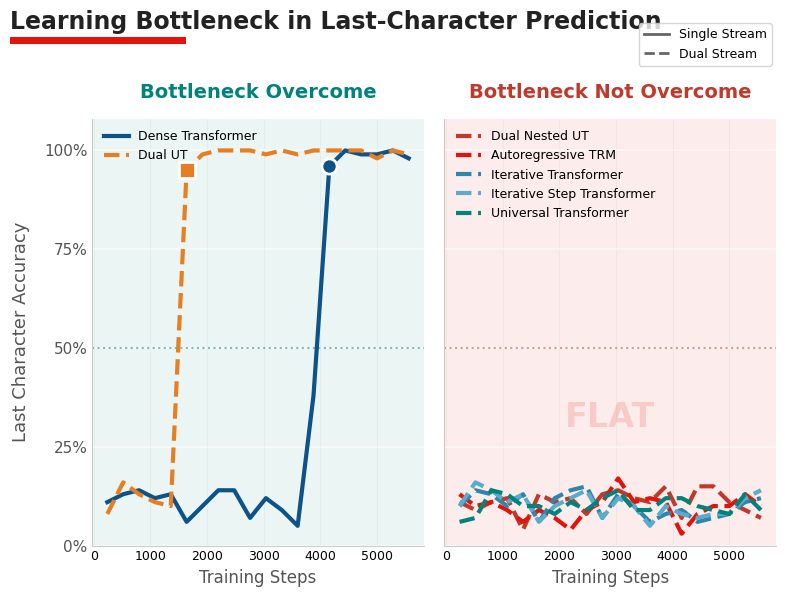

In [42]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =============================================================================
# STYLE SETUP (from your notebook)
# =============================================================================
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica Neue', 'Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.8,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

# =============================================================================
# MODEL CONFIGURATION
# =============================================================================
# Models that eventually overcome the bottleneck
LEARNERS = {
    'gpt':        {'name': 'Dense Transformer',          'color': '#0D5288', 'dual': False},
    'ut_level1':  {'name': 'Dual UT',                    'color': '#E67E22', 'dual': True},
}

# Models that NEVER overcome the bottleneck
NON_LEARNERS = {
    'ut_level2':  {'name': 'Dual Nested UT',              'color': '#C0392B', 'dual': True},
    'trm':        {'name': 'Autoregressive TRM', 'color': '#E3120B', 'dual': True},
   'gpt_level1': {'name': 'Iterative Transformer',      'color': '#2E86AB', 'dual': False},
    'gpt_level2': {'name': 'Iterative Step Transformer', 'color': '#5AACCC', 'dual': False},
    'ut':         {'name': 'Universal Transformer',      'color': '#00837B', 'dual': False},
}

CATEGORY_BG = {
    'Learns': '#EBF5F4',      # Light teal - success
    'Never Learns': '#FCECEB', # Light red - failure
}

# =============================================================================
# LOAD AND FILTER DATA
# =============================================================================
compute_budget = 24
df = lg_h[lg_h['compute_budget'] == compute_budget].copy()
df = df[df['task'] == 'addition'].copy()
df = df[df['model'].isin(model_order)].copy()
#df = df['']
#df =
# pi_h[pi_h['compute_budget'] == compute_budget].copy()

# =============================================================================
# FIGURE: Two-Panel Learning Bottleneck Comparison
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(8, 6), sharey=True)
fig.patch.set_facecolor('white')

metric = 'L10_last_char_acc'

# --- LEFT PANEL: Models that LEARN ---
ax = axes[0]
ax.set_facecolor(CATEGORY_BG['Learns'])

for model, config in LEARNERS.items():
    model_data = df[df['model'] == model]
    if len(model_data) > 0:
        grouped = model_data.groupby('step')[metric].mean()
        # Dual stream models get dashed lines
        linestyle = '--' if config['dual'] else '-'
        
        ax.plot(grouped.index * 40, grouped.values,
                color=config['color'], 
                linewidth=3,
                linestyle=linestyle,
                label=config['name'],
                zorder=3)
        
        # Mark the breakthrough point (first step above 0.5)
        above_thresh = grouped[grouped > 0.5]
        if len(above_thresh) > 0:
            trans_step = above_thresh.index[0]
            trans_val = above_thresh.iloc[0]
            marker = 's' if config['dual'] else 'o'
            ax.scatter([trans_step * 40], [trans_val], 
                      color=config['color'], s=120, zorder=4,
                      edgecolor='white', linewidth=2, marker=marker)

ax.set_title('Bottleneck Overcome', fontsize=14, fontweight='bold', color='#00837B', pad=15)
ax.set_xlabel('Training Steps', fontsize=12, color='#555555')
ax.set_ylabel('Last Character Accuracy', fontsize=13, color='#555555', labelpad=10)
ax.set_ylim(0, 1.08)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0%', '25%', '50%', '75%', '100%'], fontsize=11, color='#555555')
ax.yaxis.grid(True, linestyle='-', alpha=0.5, color='white', linewidth=1.5, zorder=1)
ax.axhline(y=0.5, color='#00837B', linestyle=':', linewidth=1.5, alpha=0.5, zorder=2)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')
ax.tick_params(axis='both', length=0)
ax.legend(loc='upper left', frameon=False, fontsize=9)

# --- RIGHT PANEL: Models that NEVER LEARN ---
ax = axes[1]
ax.set_facecolor(CATEGORY_BG['Never Learns'])

for model, config in NON_LEARNERS.items():
    model_data = df[df['model'] == model]
    if len(model_data) > 0:
        grouped = model_data.groupby('step')[metric].mean()
        ax.plot(grouped.index * 40, grouped.values,
                color=config['color'], 
                linewidth=3,
                linestyle='--',
                label=config['name'],
                zorder=3)

ax.set_title('Bottleneck Not Overcome', fontsize=14, fontweight='bold', color='#C0392B', pad=15)
ax.set_xlabel('Training Steps', fontsize=12, color='#555555')
ax.axhline(y=0.5, color='#C0392B', linestyle=':', linewidth=1.5, alpha=0.5, zorder=2)
ax.yaxis.grid(True, linestyle='-', alpha=0.5, color='white', linewidth=1.5, zorder=1)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')
ax.tick_params(axis='both', length=0)
ax.legend(loc='upper left', frameon=False, fontsize=9)

# Add "FLAT" annotation
ax.text(0.5, 0.3, 'FLAT', transform=ax.transAxes, fontsize=24, 
        color='#E3120B', alpha=0.15, fontweight='bold', 
        ha='center', va='center', rotation=0)

# --- MAIN TITLE with red accent ---
fig.text(0.02, 0.96, 'Learning Bottleneck in Last-Character Prediction', 
         fontsize=17, fontweight='bold', color='#222222')
fig.patches.append(plt.Rectangle((0.02, 0.935), 0.22, 0.012, 
                                   transform=fig.transFigure, 
                                   facecolor='#E3120B', edgecolor='none'))

# --- STYLE LEGEND (dual stream indicator) ---
# Create a small legend box explaining line styles
from matplotlib.lines import Line2D
style_legend_elements = [
    Line2D([0], [0], color='#666666', linewidth=2, linestyle='-', label='Single Stream'),
    Line2D([0], [0], color='#666666', linewidth=2, linestyle='--', label='Dual Stream'),
]
fig.legend(handles=style_legend_elements, loc='upper right', 
           bbox_to_anchor=(0.98, 0.98), frameon=True, 
           fancybox=True, shadow=False, fontsize=9,
           edgecolor='#cccccc', facecolor='white')

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig('learning_bottleneck_comparison.pdf', bbox_inches='tight', dpi=300)
plt.show()

---

Below are some additional analyses that did not end up in the camera ready paper.

# This is not an artefact of the specific H-L choices.

In [19]:
import pandas as pd
import numpy as np
import re

# =============================================================================
# PREPARE DATA
# =============================================================================
def parse_hl_config(run_name):
    match = re.search(r'hl_structure_L\d+_H(\d+)_L(\d+)', run_name)
    if match:
        return int(match.group(1)), int(match.group(2))
    return None, None

hl_analysis = hl_s.copy()
hl_analysis[['H_outer', 'L_inner']] = pd.DataFrame(
    hl_analysis['run_name'].apply(parse_hl_config).tolist(), index=hl_analysis.index
)
hl_valid = hl_analysis[hl_analysis['L10_char_acc'].notna()].copy()

# Model name mapping
model_names = {'ut_level2': 'Dual Nested UT', 'trm': 'Terminal Nested'}

# =============Add================================================================
# TABLE 1: Full Performance Data (L10 only + Quarters)
# =============================================================================
cols_to_export = ['model', 'H_outer', 'L_inner', 
                  'L10_char_acc', 'L10_seq_acc',
                  'L10_pos_q1_acc', 'L10_pos_q2_acc', 'L10_pos_q3_acc', 'L10_pos_q4_acc']

table1 = hl_valid[cols_to_export].copy()
table1['Model'] = table1['model'].map(model_names)
table1 = table1.rename(columns={
    'H_outer': 'H (outer loops)',
    'L_inner': 'L (inner loops)',
    'L10_char_acc': 'Char Acc',
    'L10_seq_acc': 'Seq Acc',
    'L10_pos_q1_acc': 'Q1 Acc',
    'L10_pos_q2_acc': 'Q2 Acc',
    'L10_pos_q3_acc': 'Q3 Acc',
    'L10_pos_q4_acc': 'Q4 Acc'
})
table1 = table1[['Model', 'H (outer loops)', 'L (inner loops)', 
                 'Char Acc', 'Seq Acc', 'Q1 Acc', 'Q2 Acc', 'Q3 Acc', 'Q4 Acc']]
table1 = table1.sort_values(['Model', 'H (outer loops)', 'L (inner loops)'])

print("="*90)
print("  TABLE 1: Full H-L Configuration Performance (L=10)")
print("="*90)
print(table1.round(3).to_string(index=False))

# =============================================================================
# TABLE 2: Summary Statistics by Model
# =============================================================================
summary_rows = []

for model in ['ut_level2', 'trm']:
    m_data = hl_valid[hl_valid['model'] == model]
    
    # Effect of H
    h_means = m_data.groupby('H_outer')['L10_char_acc'].mean()
    h_effect = h_means.max() - h_means.min()
    best_h = h_means.idxmax()
    
    # Effect of L
    l_means = m_data.groupby('L_inner')['L10_char_acc'].mean()
    l_effect = l_means.max() - l_means.min()
    best_l = l_means.idxmax()
    
    # Best overall config
    best_idx = m_data['L10_char_acc'].idxmax()
    best_row = m_data.loc[best_idx]
    
    # Quarter variance (how uniform is performance across positions?)
    q_cols = ['L10_pos_q1_acc', 'L10_pos_q2_acc', 'L10_pos_q3_acc', 'L10_pos_q4_acc']
    q_std = m_data[q_cols].mean().std()
    
    summary_rows.append({
        'Model': model_names[model],
        'Best Config': f"H={int(best_row['H_outer'])}, L={int(best_row['L_inner'])}",
        'Best Char Acc': best_row['L10_char_acc'],
        'H Effect Size': h_effect,
        'L Effect Size': l_effect,
        'Primary Driver': 'H (outer)' if h_effect > l_effect else 'L (inner)',
        'Q1-Q4 Std': q_std,
        'N Configs': len(m_data)
    })

table2 = pd.DataFrame(summary_rows)

print("\n\n" + "="*90)
print("  TABLE 2: Model Summary Statistics")
print("="*90)
print(table2.round(3).to_string(index=False))

# =============================================================================
# TABLE 3: Position (Quarter) Analysis
# =============================================================================
q_rows = []

for model in ['ut_level2', 'trm']:
    m_data = hl_valid[hl_valid['model'] == model]
    
    q_means = {
        'Q1': m_data['L10_pos_q1_acc'].mean(),
        'Q2': m_data['L10_pos_q2_acc'].mean(),
        'Q3': m_data['L10_pos_q3_acc'].mean(),
        'Q4': m_data['L10_pos_q4_acc'].mean()
    }
    
    best_q = max(q_means, key=q_means.get)
    worst_q = min(q_means, key=q_means.get)
    
    q_rows.append({
        'Model': model_names[model],
        'Q1 (Early)': q_means['Q1'],
        'Q2': q_means['Q2'],
        'Q3': q_means['Q3'],
        'Q4 (Late)': q_means['Q4'],
        'Best Position': best_q,
        'Worst Position': worst_q,
        'Q Range': max(q_means.values()) - min(q_means.values())
    })

table3 = pd.DataFrame(q_rows)

print("\n\n" + "="*90)
print("  TABLE 3: Position (Quarter) Analysis - Averaged Across Configs")
print("="*90)
print(table3.round(3).to_string(index=False))

# =============================================================================
# TABLE 4: Interaction Effect (Optimal H by L)
# =============================================================================
interaction_rows = []

for model in ['ut_level2', 'trm']:
    m_data = hl_valid[hl_valid['model'] == model]
    
    for l_inner in sorted(m_data['L_inner'].unique()):
        subset = m_data[m_data['L_inner'] == l_inner]
        if len(subset) > 0:
            best_idx = subset['L10_char_acc'].idxmax()
            best_row = subset.loc[best_idx]
            
            interaction_rows.append({
                'Model': model_names[model],
                'L (inner)': int(l_inner),
                'Optimal H': int(best_row['H_outer']),
                'Char Acc': best_row['L10_char_acc'],
                'Q1': best_row['L10_pos_q1_acc'],
                'Q4': best_row['L10_pos_q4_acc']
            })

table4 = pd.DataFrame(interaction_rows)

print("\n\n" + "="*90)
print("  TABLE 4: Interaction Effect - Optimal H Depends on L")
print("="*90)
print(table4.round(3).to_string(index=False))

# =============================================================================
# EXPORT ALL TABLES
# =============================================================================
print("\n\n" + "─"*90)
print("  EXPORT COMMANDS:")
print("─"*90)
print("""
table1.to_csv('hl_full_performance.csv', index=False)
table2.to_csv('hl_model_summary.csv', index=False)
table3.to_csv('hl_position_analysis.csv', index=False)
table4.to_csv('hl_interaction_effects.csv', index=False)

# Or export all to Excel sheets:
with pd.ExcelWriter('hl_structure_analysis.xlsx') as writer:
    table1.to_excel(writer, sheet_name='Full Performance', index=False)
    table2.to_excel(writer, sheet_name='Model Summary', index=False)
    table3.to_excel(writer, sheet_name='Position Analysis', index=False)
    table4.to_excel(writer, sheet_name='Interaction Effects', index=False)
""")
print("─"*90)

  TABLE 1: Full H-L Configuration Performance (L=10)
          Model  H (outer loops)  L (inner loops)  Char Acc  Seq Acc  Q1 Acc  Q2 Acc  Q3 Acc  Q4 Acc
 Dual Nested UT                1                1     0.147      0.0   0.390   0.087   0.117   0.077
 Dual Nested UT                1                1     0.232      0.0   0.840   0.110   0.090   0.090
 Dual Nested UT                2                1     0.136      0.0   0.395   0.067   0.087   0.083
 Dual Nested UT                2                1     0.177      0.0   0.550   0.120   0.083   0.080
 Dual Nested UT                2                2     0.145      0.0   0.365   0.103   0.100   0.087
 Dual Nested UT                2                2     0.173      0.0   0.470   0.103   0.117   0.100
 Dual Nested UT                4                2     0.121      0.0   0.220   0.097   0.093   0.107
 Dual Nested UT                4                2     0.129      0.0   0.270   0.087   0.093   0.113
 Dual Nested UT                6      

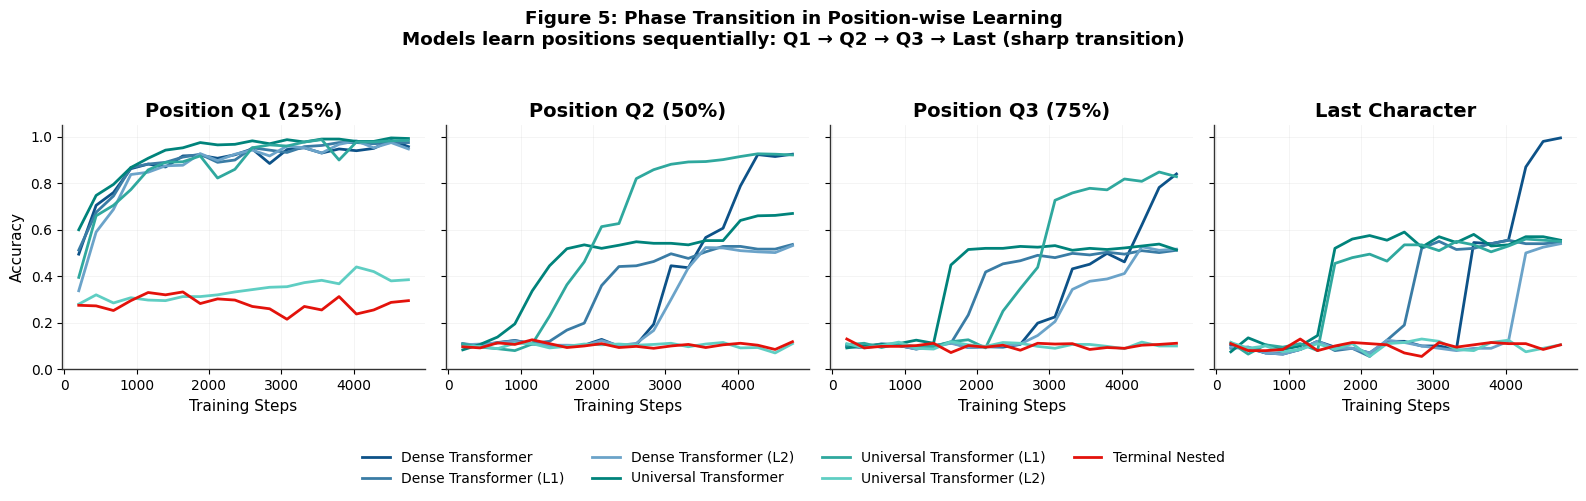

In [43]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

ECONOMIST_COLORS = {
    # --- Dense Transformer Family (Navy/Blue) ---
    'gpt': '#0D5288',           # Economist Navy (base)
    'gpt_level1': '#3A7CA5',    # Medium blue
    'gpt_level2': '#6BA3C9',    # Light blue
    
    # --- Universal Transformer Family (Teal/Green) ---
    'ut': '#00837B',            # Economist Teal (base)
    'ut_level1': '#2FA89E',     # Medium teal
    'ut_level2': '#5FCEC3',     # Light teal
    
    # --- Terminal Nested (Economist Red) ---
    'trm': '#E3120B',           # Economist Signature Red
}

MODEL_STYLES = {
    'gpt':       {'color': '#0D5288', 'name': 'Dense Transformer'},
    'gpt_level1': {'color': '#3A7CA5', 'name': 'Dense Transformer (L1)'},
    'gpt_level2': {'color': '#6BA3C9', 'name': 'Dense Transformer (L2)'},
    'ut':        {'color': '#00837B', 'name': 'Universal Transformer'},
    'ut_level1': {'color': '#2FA89E', 'name': 'Universal Transformer (L1)'},
    'ut_level2': {'color': '#5FCEC3', 'name': 'Universal Transformer (L2)'},
    'trm':       {'color': '#E3120B', 'name': 'Terminal Nested'},
}

COLORS = {k: v['color'] for k, v in MODEL_STYLES.items()}
NAMES = {k: v['name'] for k, v in MODEL_STYLES.items()}

# =============================================================================
# ECONOMIST PLOT STYLING (from your notebook)
# =============================================================================
def set_economist_style():
    """Apply Economist-inspired matplotlib styling"""
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
        'font.size': 11,
        'axes.titlesize': 14,
        'axes.titleweight': 'bold',
        'axes.labelsize': 11,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.edgecolor': '#333333',
        'axes.linewidth': 1.0,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        'legend.fontsize': 10,
        'legend.frameon': False,
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'axes.grid': True,
        'grid.alpha': 0.3,
        'grid.linewidth': 0.5,
        'grid.color': '#cccccc',
    })

set_economist_style()

# =============================================================================
# FILTER DATA
# =============================================================================
compute_budget = 24  # Focus on compute budget 24
df = pi_h[pi_h['compute_budget'] == compute_budget].copy()

# Metrics to plot (4 subplots)
METRICS = {
    'L10_pos_q1_acc': 'Position Q1 (25%)',
    'L10_pos_q2_acc': 'Position Q2 (50%)',
    'L10_pos_q3_acc': 'Position Q3 (75%)',
    'L10_last_char_acc': 'Last Character',
}

# Model order for plotting
model_order = ['gpt', 'gpt_level1', 'gpt_level2', 'ut', 'ut_level1', 'ut_level2', 'trm']
models_in_data = [m for m in model_order if m in df['model'].unique()]

# =============================================================================
# FIGURE 5: PHASE TRANSITION - 4 SUBPLOTS (one per metric)
# =============================================================================
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

for ax, (metric, title) in zip(axes, METRICS.items()):
    for model in models_in_data:
        model_data = df[df['model'] == model]
        if metric in model_data.columns:
            # Group by step and get mean
            grouped = model_data.groupby('step')[metric].mean()
            ax.plot(grouped.index * 40, grouped.values, 
                label=NAMES.get(model, model), 
                color=COLORS.get(model, '#333333'), 
                linewidth=2)
    
    ax.set_xlabel('Training Steps')
    ax.set_ylabel('Accuracy' if ax == axes[0] else '')
    ax.set_title(title)
    ax.set_ylim(0, 1.05)

# Single legend for all subplots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.02), 
           ncol=4, frameon=False)

plt.suptitle('Figure 5: Phase Transition in Position-wise Learning\n'
             'Models learn positions sequentially: Q1 → Q2 → Q3 → Last (sharp transition)',
             fontweight='bold', y=1.05)
plt.tight_layout()
#plt.savefig('phase_transition_by_position.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Analyses of lengths and embed size performance

In [ ]:
import pandas as pd
import numpy as np

# =============================================================================
# MODEL CONFIGURATION
# =============================================================================
MODEL_CONFIG = {
    'gpt':        {'name': 'Dense Transformer'},
    'gpt_level1': {'name': 'Iterative Transformer'},
    'gpt_level2': {'name': 'Iterative Step Transformer'},
    'ut':         {'name': 'Universal Transformer'},
    'ut_level1':  {'name': 'Dual UT'},
    'ut_level2':  {'name': 'Dual Nested UT'},
    'trm':        {'name': 'Autoregressive TRM'},
}

model_order = ['gpt', 'gpt_level1', 'gpt_level2', 'ut', 'ut_level1', 'ut_level2', 'trm']
lengths = ['L10', 'L20', 'L30']
embd_sizes = ['192', '384']

# =============================================================================
# GET DATA
# =============================================================================
df = pi_h[pi_h['compute_budget'] == 24].copy()

# Get last 3 time steps per run
df_last3 = df.groupby('run_id').apply(lambda x: x.nlargest(3, 'step')).reset_index(drop=True)

# =============================================================================
# COMPUTE MEAN ± SEM FOR EACH MODEL / EMBEDDING SIZE
# =============================================================================
table_data = []

for model in model_order:
    row = {'Architecture': MODEL_CONFIG[model]['name']}
    
    for length in lengths:
        metric = f'{length}_first_char_acc'
        
        for embd in embd_sizes:
            # Filter by model and embedding size
            mask = (df_last3['model'] == model) & (df_last3['run_name'].str.contains(f'embd{embd}'))
            model_df = df_last3[mask]
            
            col_key = (length, f'embd{embd}')
            
            if len(model_df) > 0:
                mean_val = model_df[metric].mean()
                std_val = model_df[metric].std()
                sem_val = std_val / np.sqrt(len(model_df))
                row[col_key] = f"{mean_val:.1%} ± {sem_val:.1%}"
            else:
                row[col_key] = "—"
    
    table_data.append(row)

# =============================================================================
# BUILD MULTI-INDEX DATAFRAME
# =============================================================================
# Create MultiIndex columns
multi_cols = pd.MultiIndex.from_tuples(
    [(length, f'embd{embd}') for length in lengths for embd in embd_sizes],
    names=['Length', 'Embedding']
)

# Extract data into proper format
data_matrix = []
for row in table_data:
    data_matrix.append([row.get((length, f'embd{embd}'), '—') 
                        for length in lengths for embd in embd_sizes])

table_df = pd.DataFrame(
    data_matrix,
    columns=multi_cols,
    index=[row['Architecture'] for row in table_data]
)

print(table_df.to_latex())

\begin{tabular}{lllllll}
\toprule
Length & \multicolumn{2}{r}{L10} & \multicolumn{2}{r}{L20} & \multicolumn{2}{r}{L30} \\
Embedding & embd192 & embd384 & embd192 & embd384 & embd192 & embd384 \\
\midrule
Dense Transformer & 99.3% ± 0.7% & 99.3% ± 0.3% & 72.3% ± 0.3% & 14.0% ± 1.2% & 63.3% ± 0.9% & 9.3% ± 3.8% \\
Iterative Transformer & 99.7% ± 0.3% & 100.0% ± 0.0% & 68.3% ± 0.3% & 71.0% ± 1.2% & 64.0% ± 0.0% & 50.0% ± 3.2% \\
Iterative Step Transformer & 99.7% ± 0.3% & 98.0% ± 1.0% & 70.0% ± 2.9% & 29.3% ± 3.8% & 61.0% ± 0.6% & 33.0% ± 6.2% \\
Universal Transformer & 99.3% ± 0.7% & 100.0% ± 0.0% & 71.7% ± 0.9% & 61.0% ± 2.6% & 64.7% ± 0.9% & 61.0% ± 0.0% \\
Dual UT & 99.7% ± 0.3% & 99.3% ± 0.3% & 71.0% ± 0.6% & 47.7% ± 0.9% & 63.3% ± 0.7% & 38.7% ± 0.9% \\
Dual Nested UT & 88.0% ± 2.1% & 52.3% ± 1.5% & 64.0% ± 3.8% & 26.0% ± 1.2% & 63.7% ± 2.0% & 20.7% ± 0.3% \\
Autoregressive TRM & 27.0% ± 4.0% & 61.7% ± 2.8% & 9.3% ± 1.9% & 54.7% ± 2.4% & 13.3% ± 2.3% & 58.7% ± 1.8% \\
\bottomrule
\e

/tmp/ipykernel_739696/4167013152.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_last3 = df.groupby('run_id').apply(lambda x: x.nlargest(3, 'step')).reset_index(drop=True)


# Generalization performance across longer sequences

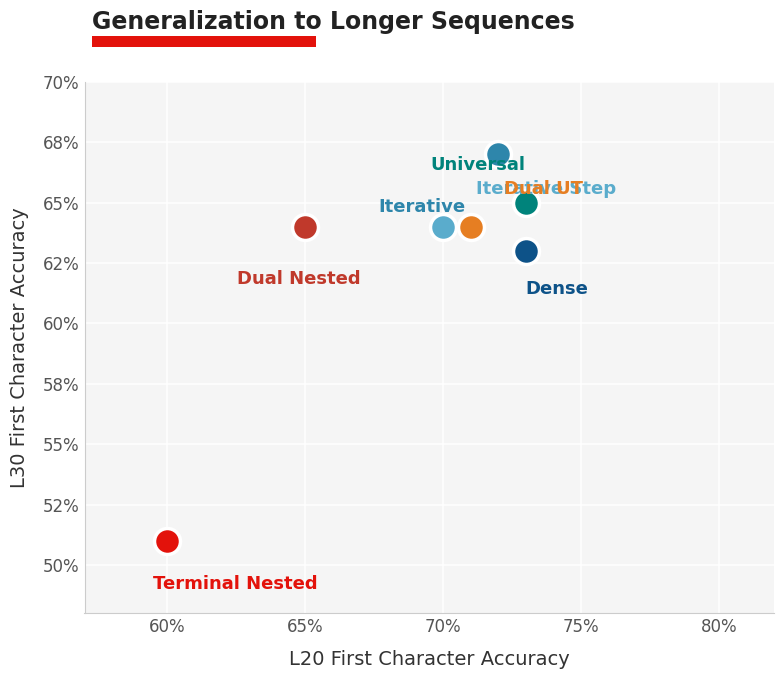

In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =============================================================================
# STYLE SETUP
# =============================================================================
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica Neue', 'Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.8,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

# =============================================================================
# MODEL CONFIGURATION
# =============================================================================
MODEL_CONFIG = {
    'gpt':        {'name': 'Dense',           'color': '#0D5288'},
    'gpt_level1': {'name': 'Iterative',       'color': '#2E86AB'},
    'gpt_level2': {'name': 'Iterative Step',  'color': '#5AACCC'},
    'ut':         {'name': 'Universal',       'color': '#00837B'},
    'ut_level1':  {'name': 'Dual UT',         'color': '#E67E22'},
    'ut_level2':  {'name': 'Dual Nested',     'color': '#C0392B'},
    'trm':        {'name': 'Terminal Nested', 'color': '#E3120B'},
}

model_order = ['gpt', 'gpt_level1', 'gpt_level2', 'ut', 'ut_level1', 'ut_level2', 'trm']

# =============================================================================
# GET DATA
# =============================================================================
#pi_h = pd.read_csv("/Users/pauliusrauba/Desktop/trm-data/paraminf_scaling_history.csv")
df = pi_h[(pi_h['compute_budget'] == 24) & (pi_h['run_name'].str.contains('embd192'))].copy()
best_results = df.loc[df.groupby('model')['L10_char_acc'].idxmax()]

# =============================================================================
# SCATTER PLOT: L20 vs L30 First Character Accuracy
# =============================================================================
fig, ax = plt.subplots(figsize=(8, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('#F5F5F5')

# Collect points and plot
l20_vals, l30_vals = [], []
plot_data = []

for model in model_order:
    row = best_results[best_results['model'] == model]
    if len(row) > 0:
        config = MODEL_CONFIG[model]
        l20 = row['L20_first_char_acc'].values[0]
        l30 = row['L30_first_char_acc'].values[0]
        l20_vals.append(l20)
        l30_vals.append(l30)
        plot_data.append({'model': model, 'l20': l20, 'l30': l30, 'config': config})

# Plot markers
for d in plot_data:
    ax.scatter(d['l20'], d['l30'], 
               color=d['config']['color'], 
               s=350, 
               zorder=3,
               edgecolor='white', 
               linewidth=2.5)

# Smart label placement
label_offsets = {
    'gpt':        (0.0, -0.012, 'left', 'top'),
    'gpt_level1': (-0.012, -0.018, 'right', 'top'),
    'gpt_level2': (0.012, 0.012, 'left', 'bottom'),
    'ut':         (-0.00, 0.012, 'right', 'bottom'),
    'ut_level1':  (0.012, 0.012, 'left', 'bottom'),
    'ut_level2':  (0.020, -0.018, 'right', 'top'),
    'trm':        (-0.005, -0.014, 'left', 'top'),
}

for d in plot_data:
    ox, oy, ha, va = label_offsets.get(d['model'], (0.012, 0.012, 'left', 'bottom'))
    ax.annotate(d['config']['name'], 
                (d['l20'], d['l30']), 
                xytext=(d['l20'] + ox, d['l30'] + oy),
                fontsize=13, 
                color=d['config']['color'], 
                fontweight='bold',
                ha=ha, 
                va=va)

# Dynamic axis limits based on data with padding
x_padding = 0.03
y_padding = 0.03
x_min, x_max = min(l20_vals) - x_padding, max(l20_vals) + x_padding + 0.06  # extra for labels
y_min, y_max = min(l30_vals) - y_padding, max(l30_vals) + y_padding

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

# Grid - white lines on gray background (matches line plot style)
ax.yaxis.grid(True, linestyle='-', alpha=0.7, color='white', linewidth=1.5, zorder=1)
ax.xaxis.grid(True, linestyle='-', alpha=0.7, color='white', linewidth=1.5, zorder=1)

# Axis labels
ax.set_xlabel('L20 First Character Accuracy', fontsize=14, color='#333333', labelpad=10)
ax.set_ylabel('L30 First Character Accuracy', fontsize=14, color='#333333', labelpad=10)

# Format tick labels as percentages
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.tick_params(axis='both', labelsize=12, colors='#555555', length=0)

# Clean spines
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

# Title with red accent bar
fig.text(0.125, 0.94, 'Generalization to Longer Sequences', 
         fontsize=17, fontweight='bold', color='#222222')
fig.patches.append(plt.Rectangle((0.125, 0.915), 0.28, 0.015, 
                                   transform=fig.transFigure, 
                                   facecolor='#E3120B', edgecolor='none'))

plt.tight_layout(rect=[0, 0, 1, 0.90])
#plt.savefig('generalization_scatter.pdf', bbox_inches='tight', dpi=300)
plt.show()